## Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)


KeyError: "['Unnamed: 0'] not found in axis"

In [5]:
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [7]:
df.drop('year',axis=1,inplace=True)
df.drop('month',axis=1,inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

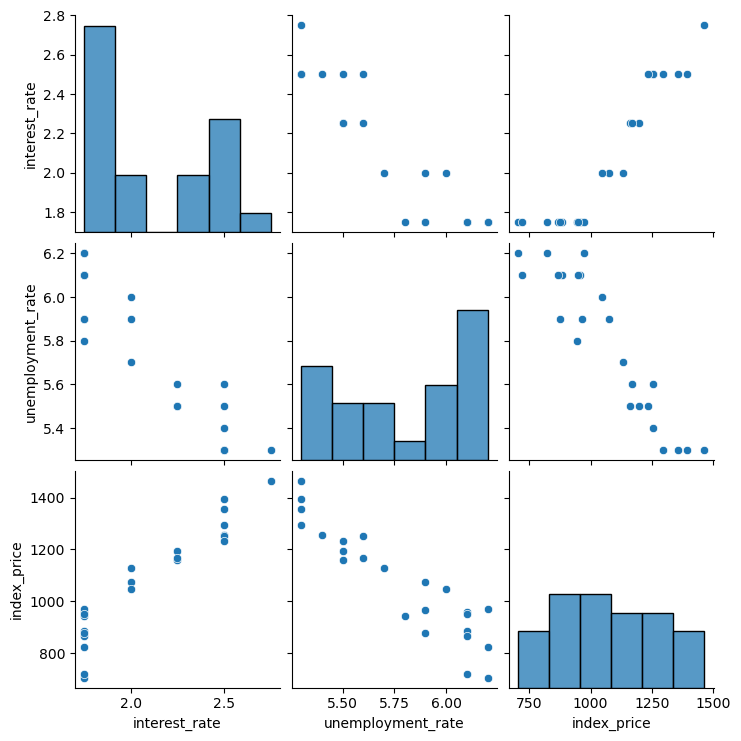

In [9]:
sns.pairplot(df)

In [11]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

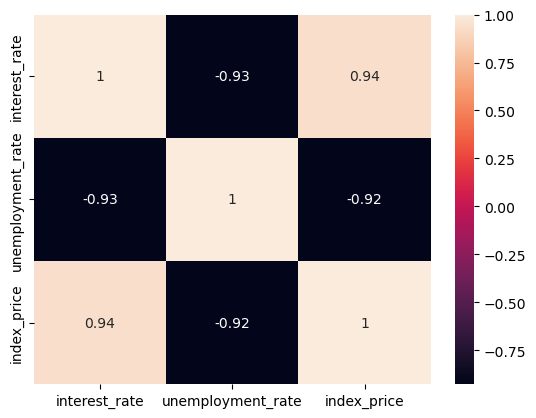

In [10]:
sns.heatmap(df.corr(),annot=True)

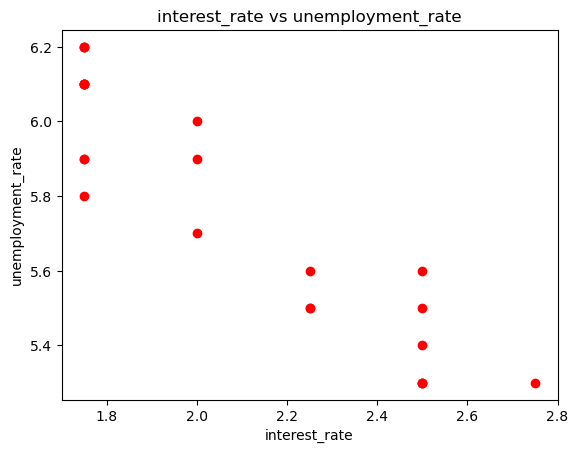

In [ ]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],c='red')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.title('interest_rate vs unemployment_rate')
plt.show()

In [14]:
## independent and dependent variable
X=df[['interest_rate','unemployment_rate']]
y=df['index_price']

In [15]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [16]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [17]:
## train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

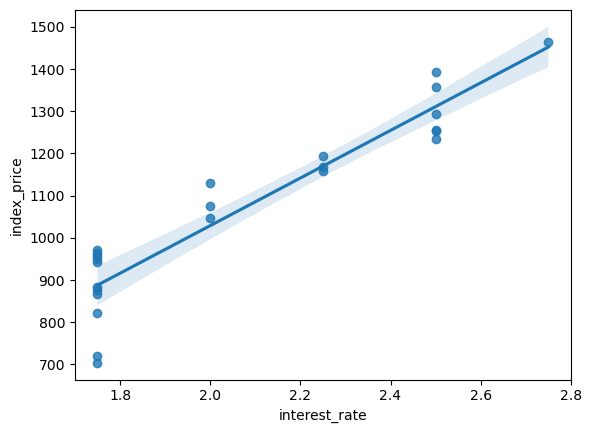

In [18]:
sns.regplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

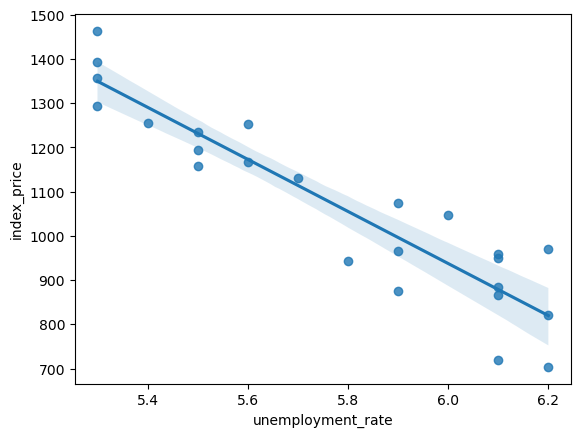

In [19]:
sns.regplot(x='unemployment_rate',y='index_price',data=df)

In [20]:
## standardize the data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
## Linear regression model
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lr.coef_

array([  88.27275507, -116.25716066])

In [23]:
lr.intercept_

np.float64(1053.4444444444443)

In [24]:
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficients: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443


In [26]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(lr,X_train_scaled,y_train,scoring='neg_mean_squared_error',cv=3)
print("Cross-validation scores:", scores)

Cross-validation scores: [-4921.61331265 -7686.87497294 -5135.9962549 ]


In [28]:
np.mean(scores)

np.float64(-5914.82818016239)

In [29]:
## prediction
y_pred=lr.predict(X_test_scaled)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [30]:
## performance evaluation
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
r2_adj=1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1)
rmse=np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Adjusted R-squared:", r2_adj)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 5793.762887712579
Mean Absolute Error: 59.935781523235526
R-squared: 0.8278978091457142
Adjusted R-squared: 0.713163015242857
Root Mean Squared Error: 76.11677139574812


## Assumption

<Axes: xlabel='index_price', ylabel='Count'>

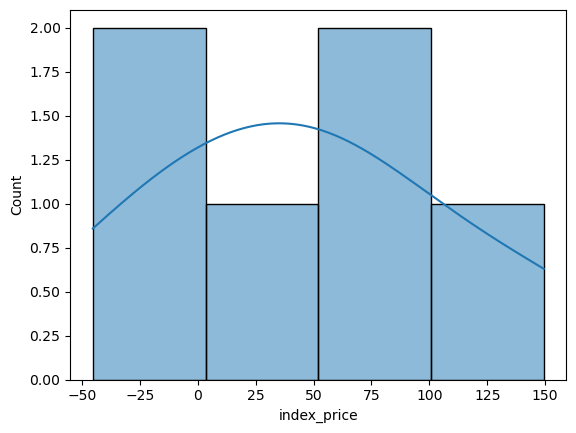

In [31]:
## assumption checking
residuals=y_test-y_pred
sns.histplot(residuals, kde=True)

<Axes: xlabel='index_price', ylabel='Density'>

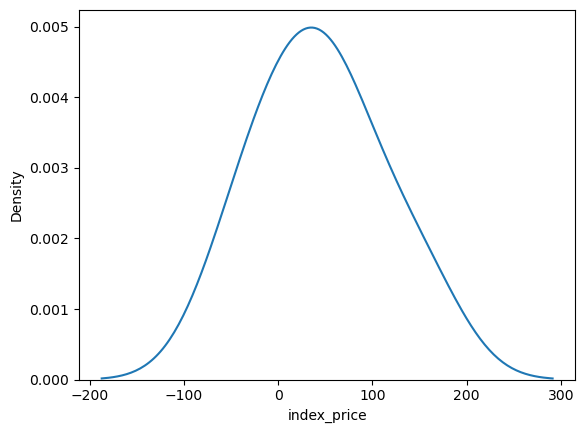

In [33]:
sns.distplot(residuals, hist=False, kde=True)

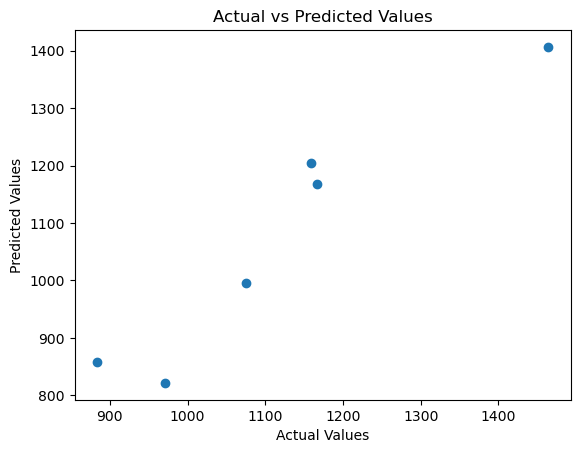

In [32]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

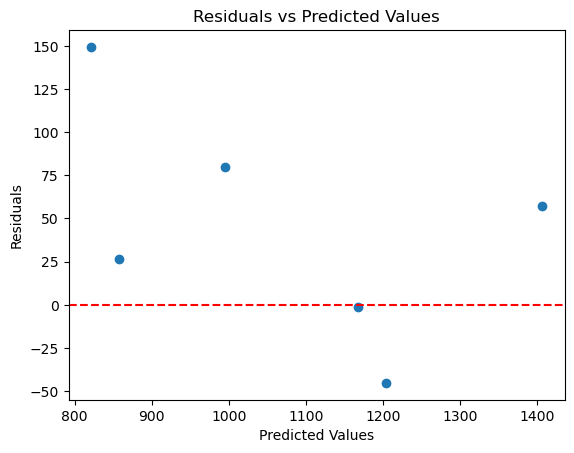

In [34]:
## scatter plot of residuals vs predicted values
plt.scatter(y_pred,residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

In [35]:
## OLS regression using statsmodels
X_train_scaled_sm=sm.add_constant(X_train_scaled)
model=sm.OLS(y_train,X_train_scaled_sm).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            index_price   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     69.88
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.50e-08
Time:                        11:52:23   Log-Likelihood:                -100.85
No. Observations:                  18   AIC:                             207.7
Df Residuals:                      15   BIC:                             210.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1053.4444     16.941     62.183      0.0